In [1]:
import pandas as pd
import numpy as np

In [2]:
data = {
    "driver_id": ["DRV-001", "DRV-002", "DRV-003", "DRV-004", "DRV-005"],
    "driver_name": ["Driver A", "Driver B", "Driver C", "Driver D", "Driver E"],
    "avg_speed_kph": [82, 58, 94, 65, 71],
    "delivery_time_mins": [30, 45, 22, 38, 41],
    "scheduled_time_mins": [35, 40, 30, 35, 45],
    "hard_braking_events": [4, 0, 7, 1, 2]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
# Calculate a quick operational metric: Delivery Delay
df["delay_mins"] = df["delivery_time_mins"] - df["scheduled_time_mins"]
df.head()

,driver_id,driver_name,avg_speed_kph,delivery_time_mins,scheduled_time_mins,hard_braking_events,delay_mins
0,DRV-001,Driver A,82,30,35,4,-5
1,DRV-002,Driver B,58,45,40,0,5
2,DRV-003,Driver C,94,22,30,7,-8
3,DRV-004,Driver D,65,38,35,1,3
4,DRV-005,Driver E,71,41,45,2,-4


In [5]:
def classify_driver_risk(row):
    """
    Classifies risk based on overspeeding thresholds and aggressive driving events.
    Standard city/expressway blended threshold set at 75 km/h.
    """
    # High Risk: Speeding significantly OR showing aggressive braking behaviors
    if row["avg_speed_kph"] > 75 or row["hard_braking_events"] >= 3:
        return "High Risk"
    elif row["avg_speed_kph"] < 40:
        return "Sub-optimal Speed"
    else:
        return "Normal"

In [6]:
# Apply safety risk rules
df["risk_profile"] = df.apply(classify_driver_risk, axis=1)

In [7]:
# Calculate a performance efficiency score (%) 
# (Scheduled Time / Actual Time) * 100 capped mathematically at 100%
df["efficiency_score"] = np.minimum((df["scheduled_time_mins"] / df["delivery_time_mins"]) * 100, 100).round(2)

In [8]:
# Display the clean analytics dataframe
df[["driver_id", "driver_name", "avg_speed_kph", "risk_profile", "efficiency_score"]]

,driver_id,driver_name,avg_speed_kph,risk_profile,efficiency_score
0,DRV-001,Driver A,82,High Risk,100.00
1,DRV-002,Driver B,58,Normal,88.89
2,DRV-003,Driver C,94,High Risk,100.00
3,DRV-004,Driver D,65,Normal,92.11
4,DRV-005,Driver E,71,Normal,100.00


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

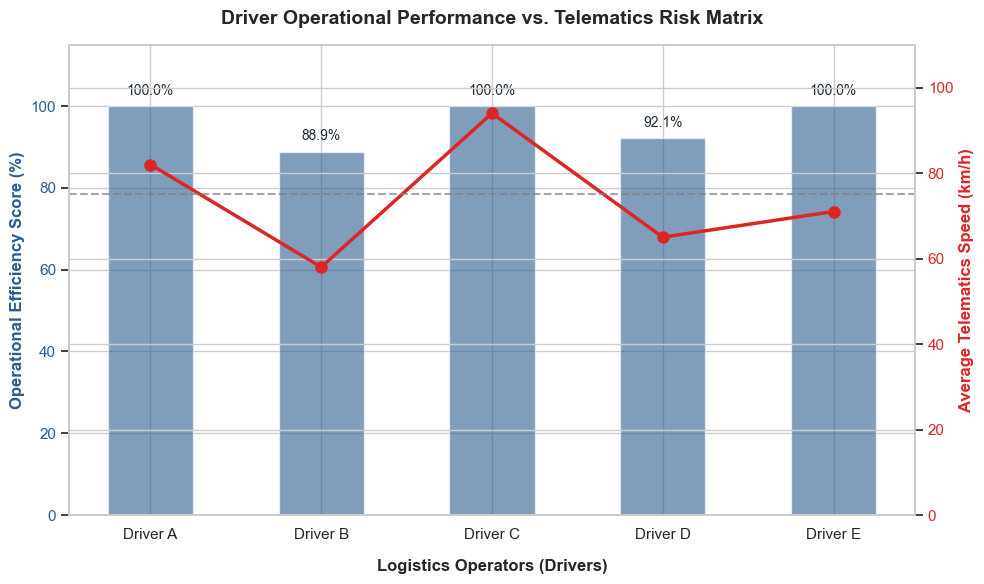

In [11]:
# Set a clean, professional aesthetic
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

# Data from our ongoing case study
drivers = ["Driver A", "Driver B", "Driver C", "Driver D", "Driver E"]
efficiency = [100.0, 88.89, 100.0, 92.11, 100.0]
speeds = [82, 58, 94, 65, 71]

# 1. Plot Efficiency Scores as a Bar Chart (Primary Y-Axis)
color_bar = '#2b5c8f'
bars = ax1.bar(drivers, efficiency, color=color_bar, alpha=0.6, width=0.5, label="Efficiency (%)")
ax1.set_xlabel("Logistics Operators (Drivers)", fontsize=12, fontweight='bold', labelpad=12)
ax1.set_ylabel("Operational Efficiency Score (%)", color=color_bar, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.set_ylim(0, 115)

# Add values on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{round(yval, 1)}%", ha='center', va='bottom', fontsize=10, color='#1f2937')

# 2. Instantiate a second axes that shares the same x-axis for Telematics Speeds
ax2 = ax1.twinx()  
color_line = '#dc2626'

# Plot Average Speeds as a Line Graph (Secondary Y-Axis)
ax2.plot(drivers, speeds, color=color_line, marker='o', linewidth=2.5, markersize=8, label="Avg Speed (km/h)")
ax2.set_ylabel("Average Telematics Speed (km/h)", color=color_line, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 110)

# Add a safety threshold line at 75 km/h
ax2.axhline(y=75, color='gray', linestyle='--', alpha=0.7, label="Risk Threshold (75 km/h)")

# Layout adjustments and Title
plt.title("Driver Operational Performance vs. Telematics Risk Matrix", fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()

# Save the plot automatically as an image asset for your portfolio package
plt.savefig("driver_performance.png", dpi=300)
plt.show()